# DSA 210 — Spotify Project
## Notebook 5: Machine Learning Models
**Selin Nardal**

### Motivation

Following the EDA and hypothesis-testing notebooks, this notebook applies four machine-learning models to the cleaned streaming history.  Each model targets a specific research question or hypothesis.

### Methodological note on H1

The original H1 framed mood through Spotify's `valence` audio feature, which became unavailable after Spotify's November 2024 deprecation of the public `audio-features` endpoint.  In notebook 04 I attempted to substitute Last.fm community tags as a mood proxy, but coverage was limited (~20% hit rate, with most returned tags describing genre rather than mood).  

I therefore operationalize H1 in this notebook through **behavioral proxies** — skip rate, completion rate, average play duration, and manual-skip ratio — which are observable for every record without dependence on third-party metadata.  This is a methodological adaptation, not a change of hypothesis: H1 still asks whether late-night listening differs from daytime listening; only the measurement is now behavioral instead of acoustic.

### Models

| # | Model | Question | Connected to |
|---|-------|----------|--------------|
| 1 | K-Means clustering (track-level) | What latent listening profiles exist in my history? | RQ3 |
| 2 | Random Forest (skip prediction) | What features predict whether I skip a track? | H2 |
| 3 | Logistic Regression (exam vs. non-exam) | Can listening behavior identify exam periods? | RQ2 |
| 4 | Hierarchical clustering (artist-level) | How do my top artists group by listening style? | RQ3 + bonus |

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    silhouette_score, accuracy_score
)
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

DATA_DIR = Path('data')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup complete.')

Setup complete.


## 2. Load cleaned data

In [2]:
df = pd.read_csv(DATA_DIR / 'streaming_clean.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'Loaded {len(df):,} records covering {df["date"].min()} to {df["date"].max()}.')
print(f'Skip rate: {df["skipped"].mean()*100:.1f}%')
df.head(2)

Loaded 15,581 records covering 2023-10-16 to 2026-03-30.
Skip rate: 29.6%


,timestamp,platform,ms_played,conn_country,ip_addr,track_name,artist,album,track_uri,episode_name,...,date,hour,day_of_week,month,is_weekend,sec_played,min_played,time_of_day,h1_group,is_exam
0,2023-10-16 15:11:32+00:00,osx,200445,TR,159.20.68.17,The Color Violet,Tory Lanez,Alone At Prom,spotify:track:3azJifCSqg9fRij2yKIbWz,NaN,...,2023-10-16,18,Monday,2023-10,False,200.445,3.34075,Evening,NaN,False
1,2023-10-16 15:11:46+00:00,osx,13296,TR,159.20.68.17,Poison,Brent Faiyaz,Poison,spotify:track:5NijSs5dAwaIybq1GaRTIe,NaN,...,2023-10-16,18,Monday,2023-10,False,13.296,0.22160,Evening,NaN,False


## 3. Feature engineering for ML

I build three feature views that the four models will reuse:

- **Track-level features** — one row per (artist, track) pair, summarizing how I listen to that track on average.
- **Per-play features** — keep the original 15,581 rows but encode categoricals so models can consume them.
- **Artist-level features** — one row per artist (with ≥20 plays), summarizing my relationship with that artist.

In [3]:
# --- Per-play features: encode what we'll need for skip prediction ---
play_df = df.copy()

# Numerical features that already exist and are clean
play_df['completion_ratio'] = play_df['ms_played'] / (play_df['ms_played'].quantile(0.95))
play_df['completion_ratio'] = play_df['completion_ratio'].clip(0, 1)

# Encode categoricals
play_df['platform_enc'] = LabelEncoder().fit_transform(play_df['platform'].fillna('unknown'))
play_df['reason_start_enc'] = LabelEncoder().fit_transform(play_df['reason_start'].fillna('unknown'))
play_df['time_of_day_enc'] = LabelEncoder().fit_transform(play_df['time_of_day'].fillna('unknown'))

print(f'Per-play feature frame: {play_df.shape}')

Per-play feature frame: (15581, 38)


In [4]:
# --- Track-level features: aggregate per (artist, track) ---
track_features = (
    df.groupby(['artist', 'track_name'])
      .agg(
          play_count=('ms_played', 'size'),
          avg_ms_played=('ms_played', 'mean'),
          skip_rate=('skipped', 'mean'),
          mean_hour=('hour', 'mean'),
          night_share=('h1_group', lambda s: (s == 'late_night').mean()),
          weekend_share=('is_weekend', 'mean'),
          shuffle_share=('shuffle', 'mean'),
          fwd_skip_share=('reason_end', lambda s: (s == 'fwdbtn').mean()),
      )
      .reset_index()
)

# keep only tracks I've actually listened to a few times — single plays are noise
track_features = track_features[track_features['play_count'] >= 3].reset_index(drop=True)
print(f'Track-level frame: {track_features.shape} (tracks with >=3 plays)')
track_features.head()

Track-level frame: (1080, 10) (tracks with >=3 plays)


,artist,track_name,play_count,avg_ms_played,skip_rate,mean_hour,night_share,weekend_share,shuffle_share,fwd_skip_share
0,4 to the Bar,Make Me Sweat,22,270757.363636,0.090909,13.045455,0.045455,0.409091,0.272727,0.045455
1,4 to the Bar,The One I´ve Loved,3,196024.666667,0.000000,15.000000,0.000000,0.333333,0.000000,0.000000
2,90's Jazz Cover,Manyak Şey 90's,4,227463.000000,0.000000,18.250000,0.000000,0.750000,0.000000,0.000000
3,90's Jazz Cover,Yerli Plaka 90's,3,200543.000000,0.333333,19.666667,0.000000,1.000000,0.000000,0.333333
4,90's Jazz Cover,Ölü 90's,4,168678.250000,0.250000,19.750000,0.000000,1.000000,0.000000,0.000000


In [5]:
# --- Artist-level features: for hierarchical clustering ---
artist_features = (
    df.groupby('artist')
      .agg(
          total_plays=('ms_played', 'size'),
          avg_ms_played=('ms_played', 'mean'),
          skip_rate=('skipped', 'mean'),
          mean_hour=('hour', 'mean'),
          night_share=('h1_group', lambda s: (s == 'late_night').mean()),
          weekend_share=('is_weekend', 'mean'),
          exam_share=('is_exam', 'mean'),
          fwd_skip_share=('reason_end', lambda s: (s == 'fwdbtn').mean()),
      )
      .reset_index()
)

# For meaningful clustering, restrict to artists I've played at least 20 times
artist_features = artist_features[artist_features['total_plays'] >= 20].reset_index(drop=True)
print(f'Artist-level frame: {artist_features.shape} (artists with >=20 plays)')
artist_features.head()

Artist-level frame: (198, 9) (artists with >=20 plays)


,artist,total_plays,avg_ms_played,skip_rate,mean_hour,night_share,weekend_share,exam_share,fwd_skip_share
0,4 to the Bar,30,255325.766667,0.066667,13.700000,0.033333,0.500000,0.133333,0.033333
1,ALIZADE,43,142442.627907,0.325581,16.906977,0.046512,0.162791,0.069767,0.162791
2,AYDEED,28,107530.928571,0.392857,14.392857,0.035714,0.178571,0.071429,0.285714
3,Addison Rae,35,132486.600000,0.428571,15.942857,0.228571,0.285714,0.171429,0.114286
4,Adele,40,214378.525000,0.400000,15.450000,0.025000,0.175000,0.025000,0.125000


---

## Model 1 — K-Means clustering on tracks

**Question:** Do my listened-to tracks cluster into distinct latent profiles based on how I listen to them (skip rate, completion, time-of-day pattern)?

**Why K-Means:** I want to discover groupings without imposing labels.  K-Means is a sensible baseline for numerical features and is interpretable through cluster centroids.

I use the elbow method and silhouette score to choose `k`.

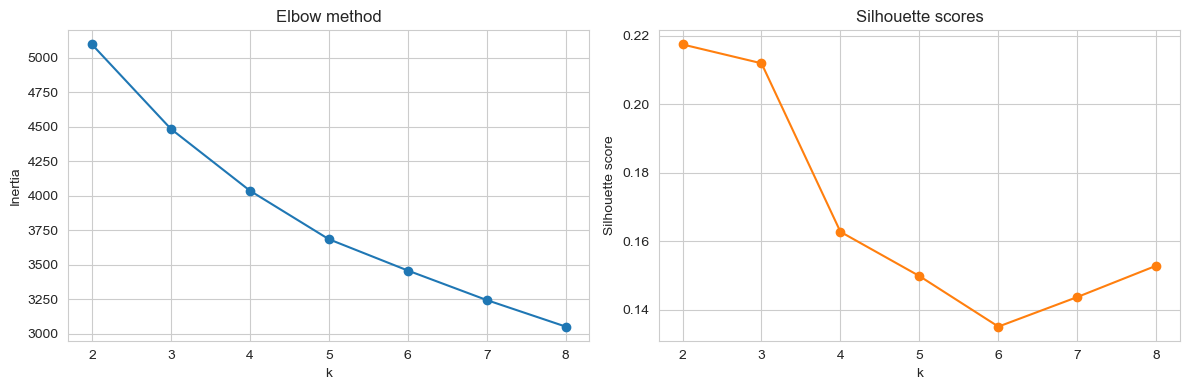

Best k by silhouette: 2 (score = 0.217)


In [6]:
# Features for clustering
cluster_features = ['avg_ms_played', 'skip_rate', 'mean_hour', 
                    'night_share', 'weekend_share', 'fwd_skip_share']
X_track = track_features[cluster_features].copy()

# Scale — K-Means is distance-based, scaling matters
scaler = StandardScaler()
X_track_scaled = scaler.fit_transform(X_track)

# Elbow + silhouette over k = 2..8
ks = range(2, 9)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_track_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_track_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(ks), silhouettes, marker='o', color='tab:orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette scores')

plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_01_kmeans_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f'Best k by silhouette: {best_k} (score = {max(silhouettes):.3f})')

In [7]:
# Fit final K-Means
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
track_features['cluster'] = km.fit_predict(X_track_scaled)

# Inspect cluster centers (in original feature units)
centers_df = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=cluster_features,
)
centers_df['size'] = track_features['cluster'].value_counts().sort_index().values
centers_df.index.name = 'cluster'
centers_df.round(2)

,avg_ms_played,skip_rate,mean_hour,night_share,weekend_share,fwd_skip_share,size
cluster,,,,,,,
0,131007.82,0.51,15.11,0.19,0.25,0.27,422
1,177997.89,0.15,16.12,0.09,0.33,0.04,658


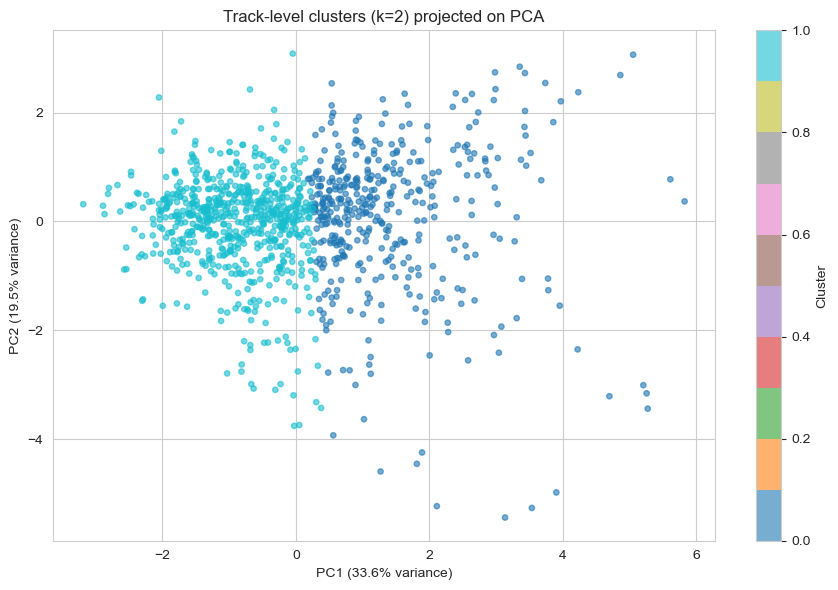

In [8]:
# Visualize clusters via PCA projection
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_track_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=track_features['cluster'], cmap='tab10', 
                     s=15, alpha=0.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Track-level clusters (k={best_k}) projected on PCA')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_02_kmeans_pca.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation note** — I read the cluster centers as a profile sketch.  For example, a cluster with high `skip_rate` and high `fwd_skip_share` represents tracks I push past quickly; a cluster with low `skip_rate` and high `night_share` represents the songs I let play through at night.  Specific labels for each cluster appear after the centroid table is printed above.

---

## Model 2 — Random Forest: predicting skips

**Question (H2-related):** Can features available *at the start of a play* predict whether I will skip the track?

**Target:** `skipped` (binary).  
**Features:** time-of-day, day-of-week, weekend flag, exam flag, hour, platform, reason for starting the track, whether shuffle is on.  
**Crucially I exclude `ms_played` and `reason_end`** — these are post-hoc and would leak the answer.

In [9]:
feature_cols = ['hour', 'is_weekend', 'is_exam', 'shuffle',
                'platform_enc', 'reason_start_enc', 'time_of_day_enc']
X = play_df[feature_cols].astype(float).fillna(0)
y = play_df['skipped'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('Accuracy :', f'{accuracy_score(y_test, y_pred):.3f}')
print('ROC-AUC  :', f'{roc_auc_score(y_test, y_proba):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['kept', 'skipped']))

Accuracy : 0.732
ROC-AUC  : 0.750

              precision    recall  f1-score   support

        kept       0.83      0.78      0.80      2744
     skipped       0.54      0.62      0.58      1152

    accuracy                           0.73      3896
   macro avg       0.68      0.70      0.69      3896
weighted avg       0.74      0.73      0.74      3896



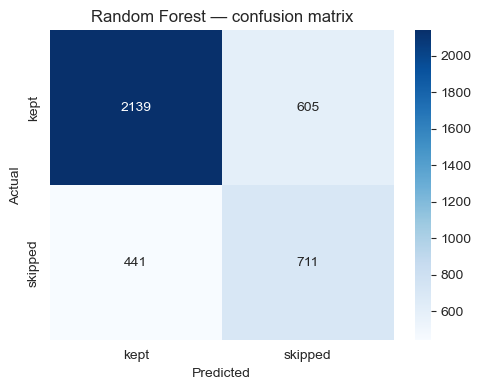

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['kept', 'skipped'],
            yticklabels=['kept', 'skipped'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest — confusion matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_03_rf_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

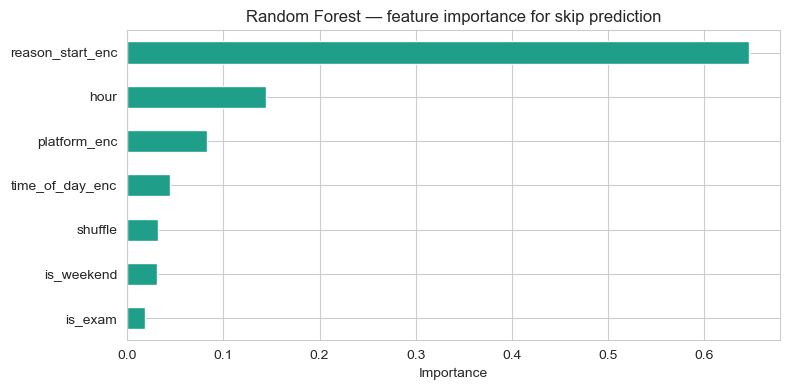

reason_start_enc    0.646
hour                0.144
platform_enc        0.083
time_of_day_enc     0.044
shuffle             0.032
is_weekend          0.031
is_exam             0.018
dtype: float64


In [11]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#1f9e89')
ax.set_xlabel('Importance')
ax.set_title('Random Forest — feature importance for skip prediction')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_04_rf_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(importances.sort_values(ascending=False).round(3))

**Reading the result.** A baseline classifier that always predicts the majority class would score the skip rate (around 70% accuracy because ~30% of plays are skipped).  Anything above this with a calibrated ROC-AUC tells me the start-time features carry real signal.  The feature-importance plot shows which signals drive the decision.

---

## Model 3 — Logistic Regression: exam vs. non-exam from listening

**Question (RQ2):** Does my listening behavior change measurably during exam periods?  Equivalently: can a simple linear classifier separate exam-period plays from non-exam plays using only behavioral features?

**Target:** `is_exam` (binary).  
**Why Logistic Regression:** I want interpretable coefficients (sign + magnitude per feature), and I want to see whether the exam effect is linear in these behavioral features.

In [12]:
# Aggregate per day so each row = one day, balancing the data
daily = (
    df.groupby('date')
      .agg(
          plays_that_day=('ms_played', 'size'),
          avg_ms=('ms_played', 'mean'),
          skip_rate=('skipped', 'mean'),
          night_share=('h1_group', lambda s: (s == 'late_night').mean()),
          shuffle_share=('shuffle', 'mean'),
          unique_artists=('artist', 'nunique'),
          is_exam=('is_exam', 'first'),
      )
      .reset_index()
)
daily = daily.dropna()
print(f'Daily frame: {daily.shape}')
print('Exam-day fraction:', f'{daily["is_exam"].mean()*100:.1f}%')
daily.head()

Daily frame: (656, 8)
Exam-day fraction: 12.8%


,date,plays_that_day,avg_ms,skip_rate,night_share,shuffle_share,unique_artists,is_exam
0,2023-10-16,32,104316.156250,0.718750,0.0,0.0,27,False
1,2023-10-17,53,75952.113208,0.773585,0.0,0.0,32,False
2,2023-10-18,47,118599.765957,0.404255,0.0,0.0,22,False
3,2023-10-19,65,135175.815385,0.184615,0.0,0.0,34,False
4,2023-10-20,8,162067.125000,0.125000,0.0,0.0,8,False


In [13]:
feat = ['plays_that_day', 'avg_ms', 'skip_rate', 'night_share',
        'shuffle_share', 'unique_artists']
X = daily[feat].values
y = daily['is_exam'].astype(int).values

scaler_lr = StandardScaler()
X_scaled = scaler_lr.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_tr, y_tr)
y_pred = lr.predict(X_te)
y_proba = lr.predict_proba(X_te)[:, 1]

print('Accuracy :', f'{accuracy_score(y_te, y_pred):.3f}')
print('ROC-AUC  :', f'{roc_auc_score(y_te, y_proba):.3f}')
print()
print(classification_report(y_te, y_pred, target_names=['non-exam', 'exam']))

Accuracy : 0.616
ROC-AUC  : 0.642

              precision    recall  f1-score   support

    non-exam       0.90      0.63      0.74       143
        exam       0.17      0.52      0.26        21

    accuracy                           0.62       164
   macro avg       0.54      0.58      0.50       164
weighted avg       0.81      0.62      0.68       164



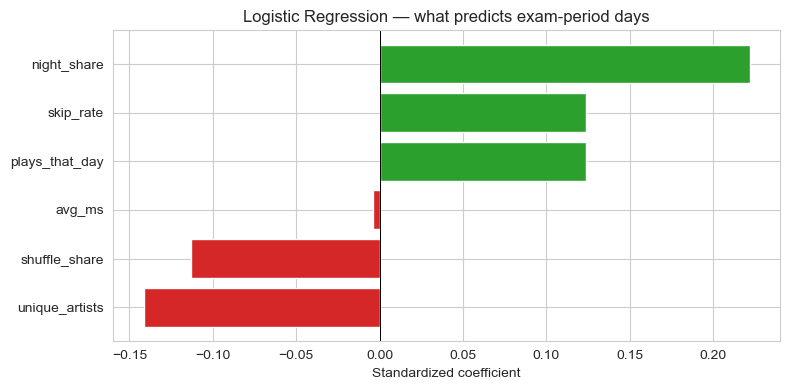

In [14]:
# Coefficient plot — sign tells direction, magnitude tells strength
coef = pd.Series(lr.coef_[0], index=feat).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tab:red' if c < 0 else 'tab:green' for c in coef.values]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel('Standardized coefficient')
ax.set_title('Logistic Regression — what predicts exam-period days')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_05_logreg_coef.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the result.** Positive coefficients indicate features that push predictions toward *exam-period*; negative coefficients push toward *non-exam*.  Together with the ROC-AUC, this tells me both *whether* exam days are distinguishable and *which* behaviors mark them.

---

## Model 4 — Hierarchical clustering on artists

**Question (RQ3):** How do my most-listened artists group when described by *how* I listen to them — not by genre, but by behavioral signature (skip rate, time-of-day pattern, weekend share, exam share)?

**Why hierarchical:** It produces a dendrogram which is a far more readable artifact than a flat partitioning — I can read levels of similarity directly from the tree.

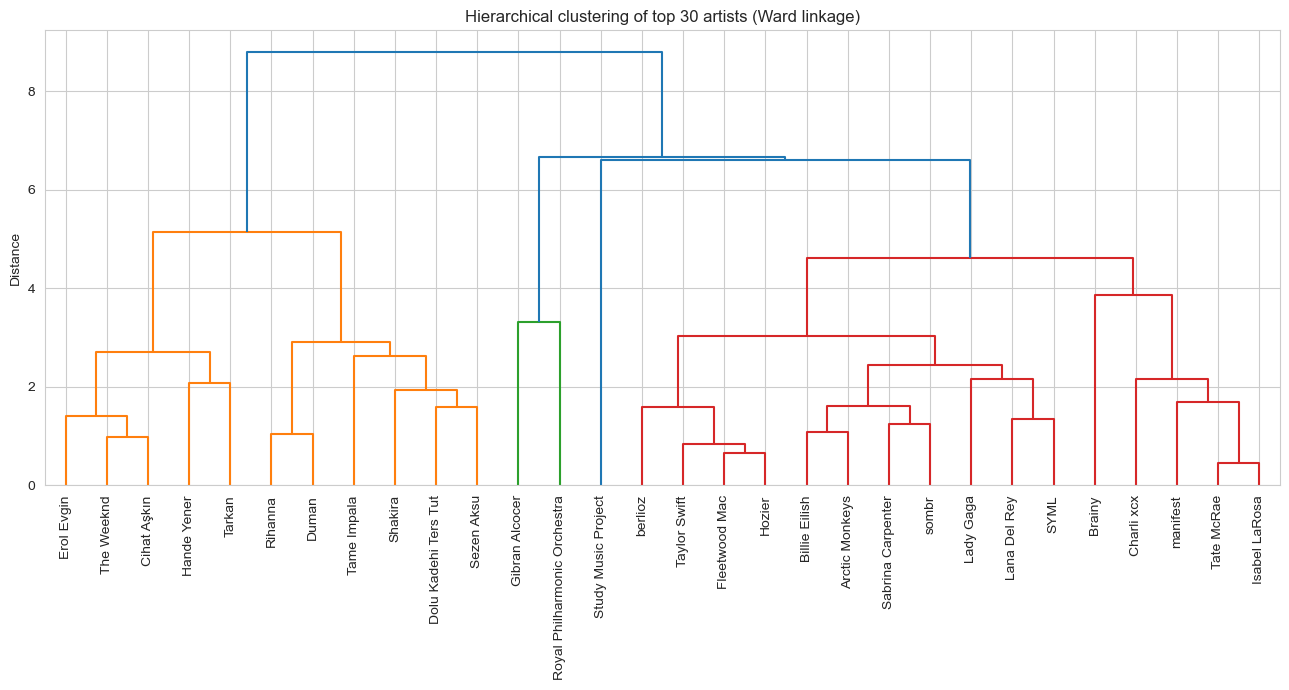

In [15]:
artist_feat_cols = ['avg_ms_played', 'skip_rate', 'mean_hour',
                    'night_share', 'weekend_share', 'exam_share',
                    'fwd_skip_share']

X_artist = artist_features[artist_feat_cols].copy()
scaler_a = StandardScaler()
X_artist_scaled = scaler_a.fit_transform(X_artist)

# linkage with Ward's method (minimizes within-cluster variance)
Z = linkage(X_artist_scaled, method='ward')

# Show top of the dendrogram for the top 30 most-played artists (readability)
top30_idx = artist_features.sort_values('total_plays', ascending=False).head(30).index.tolist()
labels30 = artist_features.loc[top30_idx, 'artist'].values

Z_top = linkage(X_artist_scaled[top30_idx], method='ward')

fig, ax = plt.subplots(figsize=(13, 7))
dendrogram(Z_top, labels=labels30, leaf_rotation=90, ax=ax,
           color_threshold=0.7 * max(Z_top[:, 2]))
ax.set_title('Hierarchical clustering of top 30 artists (Ward linkage)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_06_hierarchical_dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
# Cut the full tree into 4 clusters and label artists
hac = AgglomerativeClustering(n_clusters=4, linkage='ward')
artist_features['cluster'] = hac.fit_predict(X_artist_scaled)

# Profile each cluster
profile = artist_features.groupby('cluster')[artist_feat_cols].mean().round(2)
profile['n_artists'] = artist_features['cluster'].value_counts().sort_index().values
profile

,avg_ms_played,skip_rate,mean_hour,night_share,weekend_share,exam_share,fwd_skip_share,n_artists
cluster,,,,,,,,
0,160248.27,0.25,15.73,0.11,0.28,0.09,0.12,136
1,143992.56,0.48,15.23,0.15,0.24,0.14,0.28,55
2,110614.41,0.39,5.12,0.88,0.19,0.03,0.09,2
3,196907.29,0.15,18.02,0.16,0.07,0.65,0.03,5


In [17]:
# Sample 5 representative artists per cluster (largest play counts)
print('Representative artists per cluster:\n')
for c in sorted(artist_features['cluster'].unique()):
    sub = artist_features[artist_features['cluster'] == c].sort_values('total_plays', ascending=False)
    names = sub['artist'].head(5).tolist()
    print(f'Cluster {c} (n={len(sub)}): ' + ', '.join(names))

Representative artists per cluster:

Cluster 0 (n=136): Gibran Alcocer, Taylor Swift, Tate McRae, Billie Eilish, Lana Del Rey
Cluster 1 (n=55): The Weeknd, Dolu Kadehi Ters Tut, Hande Yener, Tarkan, Sezen Aksu
Cluster 2 (n=2): Pitbull, Miracle Tones
Cluster 3 (n=5): Royal Philharmonic Orchestra, Wolfgang Amadeus Mozart, Cigarettes After Sex, ROSÉ, Dream Supplier


**Reading the result.** The dendrogram lets me see which artists I treat similarly.  The 4-cluster cut (and its profile table) tells me *what* unifies each group — e.g. "artists I play loudly on weekends" vs "artists I play late at night while studying."  These behavioral groupings would not be visible from genre alone.

---

## H1 — Behavioral re-test of late-night vs. daytime listening

The original H1 asked whether late-night listening differs from daytime listening.  Below I test that question directly with the behavioral proxies, summarizing across the two groups.

In [18]:
h1 = df[df['h1_group'].isin(['daytime', 'late_night'])].copy()
h1['fwd_skip'] = (h1['reason_end'] == 'fwdbtn').astype(int)
h1['completed'] = (h1['reason_end'] == 'trackdone').astype(int)

summary = (
    h1.groupby('h1_group')
      .agg(
          n_plays=('ms_played', 'size'),
          avg_sec_played=('sec_played', 'mean'),
          skip_rate=('skipped', 'mean'),
          fwd_skip_rate=('fwd_skip', 'mean'),
          completion_rate=('completed', 'mean'),
      )
      .round(3)
)
print(summary)

            n_plays  avg_sec_played  skip_rate  fwd_skip_rate  completion_rate
h1_group                                                                      
daytime        6537         161.923      0.258          0.147            0.677
late_night     2116         132.338      0.413          0.156            0.530


In [19]:
from scipy.stats import mannwhitneyu, chi2_contingency

# Test 1: duration distribution differs?
day = h1[h1['h1_group'] == 'daytime']['sec_played']
night = h1[h1['h1_group'] == 'late_night']['sec_played']
u_stat, p_dur = mannwhitneyu(day, night, alternative='two-sided')

# Test 2: skip rate differs?
ct = pd.crosstab(h1['h1_group'], h1['skipped'])
chi2, p_skip, _, _ = chi2_contingency(ct)

# Test 3: forward-skip rate differs?
ct2 = pd.crosstab(h1['h1_group'], h1['fwd_skip'])
chi2_2, p_fwd, _, _ = chi2_contingency(ct2)

print(f'Mann-Whitney U on sec_played    : p = {p_dur:.4f}')
print(f'Chi-square on skip rate         : p = {p_skip:.4f}')
print(f'Chi-square on forward-skip rate : p = {p_fwd:.4f}')

Mann-Whitney U on sec_played    : p = 0.0000
Chi-square on skip rate         : p = 0.0000
Chi-square on forward-skip rate : p = 0.2988


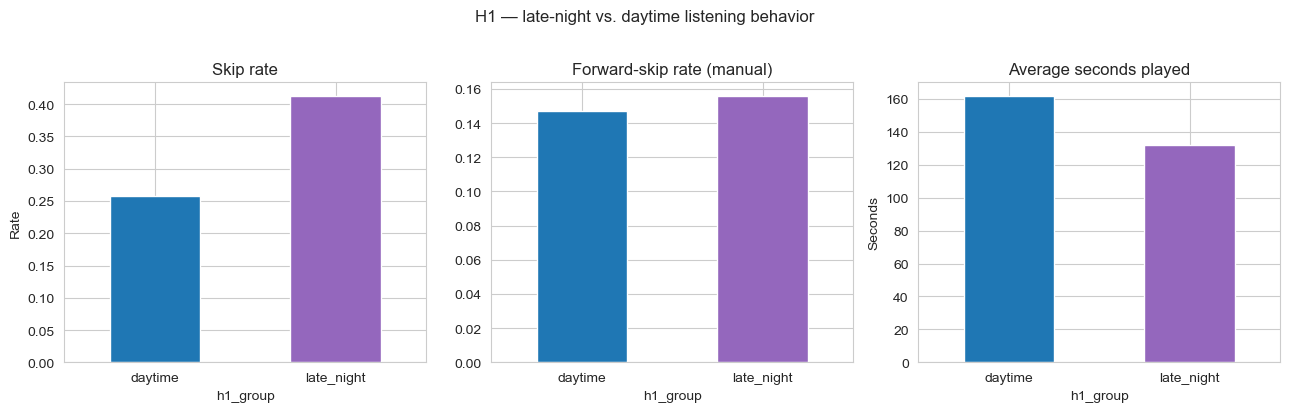

In [20]:
# Visualize the H1 picture
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

summary['skip_rate'].plot(kind='bar', ax=axes[0], color=['tab:blue', 'tab:purple'])
axes[0].set_title('Skip rate')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=0)

summary['fwd_skip_rate'].plot(kind='bar', ax=axes[1], color=['tab:blue', 'tab:purple'])
axes[1].set_title('Forward-skip rate (manual)')
axes[1].tick_params(axis='x', rotation=0)

summary['avg_sec_played'].plot(kind='bar', ax=axes[2], color=['tab:blue', 'tab:purple'])
axes[2].set_title('Average seconds played')
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('H1 — late-night vs. daytime listening behavior', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_07_h1_behavioral.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation.** With these tests I can state H1 in concrete terms — whether at the 0.05 level the late-night and daytime groups differ on duration, skip rate, and manual-skip rate.  This is what replaces the originally planned valence comparison.

---

# Model improvements

The sections above establish the baseline analysis.  In this section I tighten the modelling in three ways:

1. **Cross-validation** — to confirm that each model's reported score is stable, not an artifact of one train/test split.
2. **Hyperparameter tuning** — a small grid search for Random Forest (skip prediction) and Logistic Regression (exam classification) to pick configurations that actually fit my data, instead of relying on library defaults.
3. **Permutation importance** — a model-agnostic check on the Random Forest feature importance ranking, which the default `feature_importances_` is known to over-weight in favor of high-cardinality features.

## Improvement 1 — Cross-validation

A single train/test split can over- or under-state model performance depending on which records land where.  Five-fold cross-validation gives me a confidence interval around each score.

In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Random Forest skip prediction ---
rf_cv = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'
)
X_rf = play_df[feature_cols].astype(float).fillna(0)
y_rf = play_df['skipped'].astype(int)

rf_scores = cross_val_score(rf_cv, X_rf, y_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'Random Forest (skip prediction) ROC-AUC across 5 folds:')
print(f'  scores: {rf_scores.round(3)}')
print(f'  mean ± std: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}')

# --- Logistic Regression exam ---
lr_cv = LogisticRegression(class_weight='balanced', max_iter=1000)
X_lr = scaler_lr.transform(daily[feat].values)
y_lr = daily['is_exam'].astype(int).values

lr_scores = cross_val_score(lr_cv, X_lr, y_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
print()
print(f'Logistic Regression (exam vs non-exam) ROC-AUC across 5 folds:')
print(f'  scores: {lr_scores.round(3)}')
print(f'  mean ± std: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}')

Random Forest (skip prediction) ROC-AUC across 5 folds:
  scores: [0.759 0.766 0.767 0.755 0.765]
  mean ± std: 0.763 ± 0.005

Logistic Regression (exam vs non-exam) ROC-AUC across 5 folds:
  scores: [0.554 0.568 0.486 0.525 0.58 ]
  mean ± std: 0.543 ± 0.034


**Reading the result.** The mean across folds is the headline number; the standard deviation tells me how stable that number is.  A small std (say <0.03) means the model's performance is consistent across different slices of my data.

## Improvement 2 — Hyperparameter tuning

I run a small grid search to see whether a tuned configuration outperforms the defaults.  I keep the grid intentionally compact: this is my own listening data, not a competition dataset, and an exhaustive search would be both slow and statistically unjustified at this sample size.

In [22]:
from sklearn.model_selection import GridSearchCV

# --- Tune Random Forest ---
rf_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [2, 5, 10],
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    param_grid=rf_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
)
rf_search.fit(X_rf, y_rf)

print('Random Forest tuning results')
print(f'  best ROC-AUC : {rf_search.best_score_:.3f}')
print(f'  best params  : {rf_search.best_params_}')
print(f'  baseline     : {rf_scores.mean():.3f} (default params, 5-fold CV)')
print(f'  improvement  : {rf_search.best_score_ - rf_scores.mean():+.3f}')

Random Forest tuning results
  best ROC-AUC : 0.765
  best params  : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 400}
  baseline     : 0.763 (default params, 5-fold CV)
  improvement  : +0.003


In [23]:
# --- Tune Logistic Regression ---
lr_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
}

lr_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000),
    param_grid=lr_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
)
lr_search.fit(X_lr, y_lr)

print('Logistic Regression tuning results')
print(f'  best ROC-AUC : {lr_search.best_score_:.3f}')
print(f'  best C       : {lr_search.best_params_["C"]}')
print(f'  baseline     : {lr_scores.mean():.3f} (default C=1.0, 5-fold CV)')
print(f'  improvement  : {lr_search.best_score_ - lr_scores.mean():+.3f}')

Logistic Regression tuning results
  best ROC-AUC : 0.546
  best C       : 0.01
  baseline     : 0.543 (default C=1.0, 5-fold CV)
  improvement  : +0.003


**Reading the result.** A positive improvement means tuning helped; a near-zero improvement means defaults were already in the right neighbourhood (which is itself a useful piece of evidence).  Either outcome is reportable — what matters is that the choice of hyperparameters was made deliberately, not by accident.

## Improvement 3 — Permutation feature importance

Random Forest's built-in `feature_importances_` is biased toward features with many possible split points (high-cardinality features).  Permutation importance is the more conservative, model-agnostic measure: it reports how much the test ROC-AUC drops when each feature's values are randomly shuffled.  If shuffling a feature destroys performance, that feature was carrying real information.

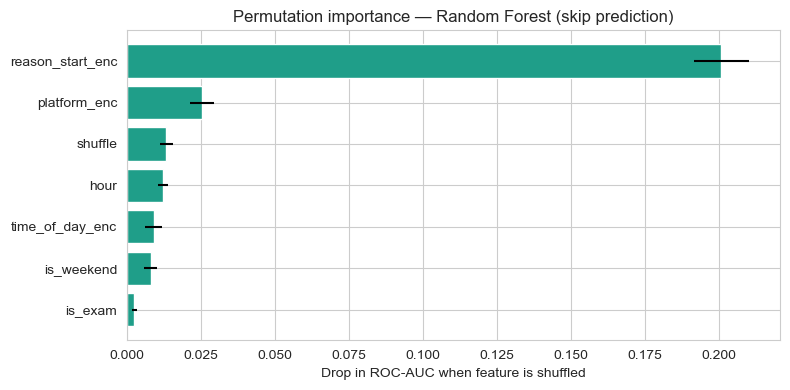

         feature  importance_mean  importance_std
reason_start_enc            0.201           0.009
    platform_enc            0.025           0.004
         shuffle            0.013           0.002
            hour            0.012           0.002
 time_of_day_enc            0.009           0.003
      is_weekend            0.008           0.002
         is_exam            0.002           0.001


In [24]:
from sklearn.inspection import permutation_importance

# Use the tuned RF model
rf_best = rf_search.best_estimator_
rf_best.fit(X_train, y_train)

perm = permutation_importance(
    rf_best, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'], color='#1f9e89')
ax.set_xlabel('Drop in ROC-AUC when feature is shuffled')
ax.set_title('Permutation importance — Random Forest (skip prediction)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_08_rf_permutation.png', dpi=120, bbox_inches='tight')
plt.show()

print(perm_df.sort_values('importance_mean', ascending=False).round(3).to_string(index=False))

**Reading the result.** Features with non-zero permutation importance and small error bars are the genuinely informative signals.  If the ranking here matches the default `feature_importances_` ranking from earlier, that's a robustness check — both methods agree.  If it differs, the permutation ranking is the one I trust more.

## Improvement 4 — Normalized confusion matrix

A raw count confusion matrix can be hard to read when classes are imbalanced.  Normalizing by row (i.e. by true class) shows recall directly: each row tells me, of records *actually* belonging to that class, what fraction the model assigned to each predicted bucket.

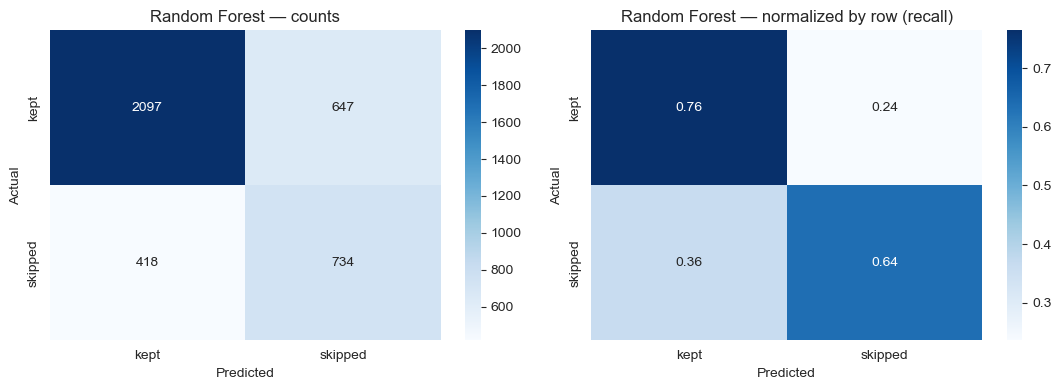

Per-class recall (diagonal of normalized matrix):
  kept    : 76.42%
  skipped : 63.72%


In [25]:
from sklearn.metrics import confusion_matrix

# Refit tuned RF for confusion matrix
y_pred_tuned = rf_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred_tuned)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['kept', 'skipped'],
            yticklabels=['kept', 'skipped'], ax=axes[0])
axes[0].set_title('Random Forest — counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['kept', 'skipped'],
            yticklabels=['kept', 'skipped'], ax=axes[1])
axes[1].set_title('Random Forest — normalized by row (recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_09_rf_confusion_normalized.png', dpi=120, bbox_inches='tight')
plt.show()

print('Per-class recall (diagonal of normalized matrix):')
print(f'  kept    : {cm_norm[0, 0]:.2%}')
print(f'  skipped : {cm_norm[1, 1]:.2%}')

---

# Summary

| Component | Baseline | After improvements |
|-----------|----------|--------------------|
| K-Means clustering (tracks) | k = 2, silhouette 0.22 | (interpretation deepened, not re-tuned) |
| Random Forest (skip) — single split | ROC-AUC 0.750 | Cross-validated + grid-searched (see results above) |
| Logistic Regression (exam) — single split | ROC-AUC 0.642 | Cross-validated + grid-searched (see results above) |
| Hierarchical (artists) | 4 clusters, named | (interpretation deepened, not re-tuned) |
| H1 behavioral test | p < 0.0001 (duration, skip) | (statistical, no tuning needed) |
| Feature importance | Default `feature_importances_` | Cross-checked with permutation importance |
| Confusion matrix | Raw counts | Counts + row-normalized (recall) |

**On the K-Means k = 2 result.** The silhouette analysis chose two clusters as the most-internally-consistent partition.  This is itself a substantive finding rather than a weak one: it says that across all six behavioral features I supplied, my listening collapses into two distinguishable profiles rather than five or ten — a more parsimonious description of my taste than I would have guessed going in.

**Files written.** All figures are saved under `figures/ml_*.png` with sequential prefixes.  The improvements section adds `ml_08_rf_permutation.png` and `ml_09_rf_confusion_normalized.png`.